## Telco Customer Data Predicting Monlthy Charges using Linear Regression

In [9]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, cross_validate, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (mean_absolute_error, mean_squared_error)

In [10]:
df= pd.read_csv("data/telco-churn.csv")
df.shape

(7043, 21)

In [11]:
df.columns.tolist()

['customerID',
 'gender',
 'SeniorCitizen',
 'Partner',
 'Dependents',
 'tenure',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'MonthlyCharges',
 'TotalCharges',
 'Churn']

In [12]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [13]:
df.sample(10)
# getting random values

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
714,4312-KFRXN,Male,0,Yes,No,72,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.40,1710.9,No
6942,3454-JFUBC,Male,1,No,No,68,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Credit card (automatic),20.00,1396,No
5088,1399-OUPJN,Female,0,Yes,Yes,57,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Bank transfer (automatic),19.75,1272.05,No
2391,7318-EIVKO,Male,0,No,No,8,Yes,Yes,DSL,No,...,No,No,Yes,No,Month-to-month,Yes,Electronic check,59.25,436.6,No
16,8191-XWSZG,Female,0,No,No,52,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,No,Mailed check,20.65,1022.95,No
5886,1709-EJDOX,Female,0,Yes,Yes,47,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.75,948.9,No
2182,2530-FMFXO,Male,0,Yes,Yes,56,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,Two year,Yes,Electronic check,103.20,5873.75,No
4916,3420-YJLQT,Female,0,No,No,2,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,No,Electronic check,79.55,151.75,No
3960,7404-JLKQG,Female,0,No,No,3,Yes,No,DSL,No,...,Yes,No,Yes,No,Month-to-month,No,Electronic check,57.55,161.45,No
3572,1730-ZMAME,Female,1,No,No,32,Yes,No,Fiber optic,No,...,No,No,No,Yes,Month-to-month,Yes,Electronic check,79.50,2665,No


In [14]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [15]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customerID,7043,7043,7590-VHVEG,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,7043,2,Male,3555,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SeniorCitizen,7043.0,NaN,NaN,NaN,0.162147,0.368612,0.0,0.0,0.0,0.0,1.0
Partner,7043,2,No,3641,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,7043,2,No,4933,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure,7043.0,NaN,NaN,NaN,32.371149,24.559481,0.0,9.0,29.0,55.0,72.0
PhoneService,7043,2,Yes,6361,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MultipleLines,7043,3,No,3390,NaN,NaN,NaN,NaN,NaN,NaN,NaN
InternetService,7043,3,Fiber optic,3096,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OnlineSecurity,7043,3,No,3498,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Data Cleaning 
Total Charges contains some blank strings so lets turn them to NaN, and then those rows can be filled with MonlthyCharges* tenure , and confirm if there are any missing values or duplicates rows left

In [16]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
print("Blank / invalid TotalCharges rows:", df["TotalCharges"].isna().sum())

df["TotalCharges"] = df["TotalCharges"].fillna(df["MonthlyCharges"] * df["tenure"])

print("Total missing values after cleaning:", int(df.isnull().sum().sum()))
print("Duplicate rows:", int(df.duplicated().sum()))

Blank / invalid TotalCharges rows: 11
Total missing values after cleaning: 0
Duplicate rows: 0


Exploratory data analysis(EDA)

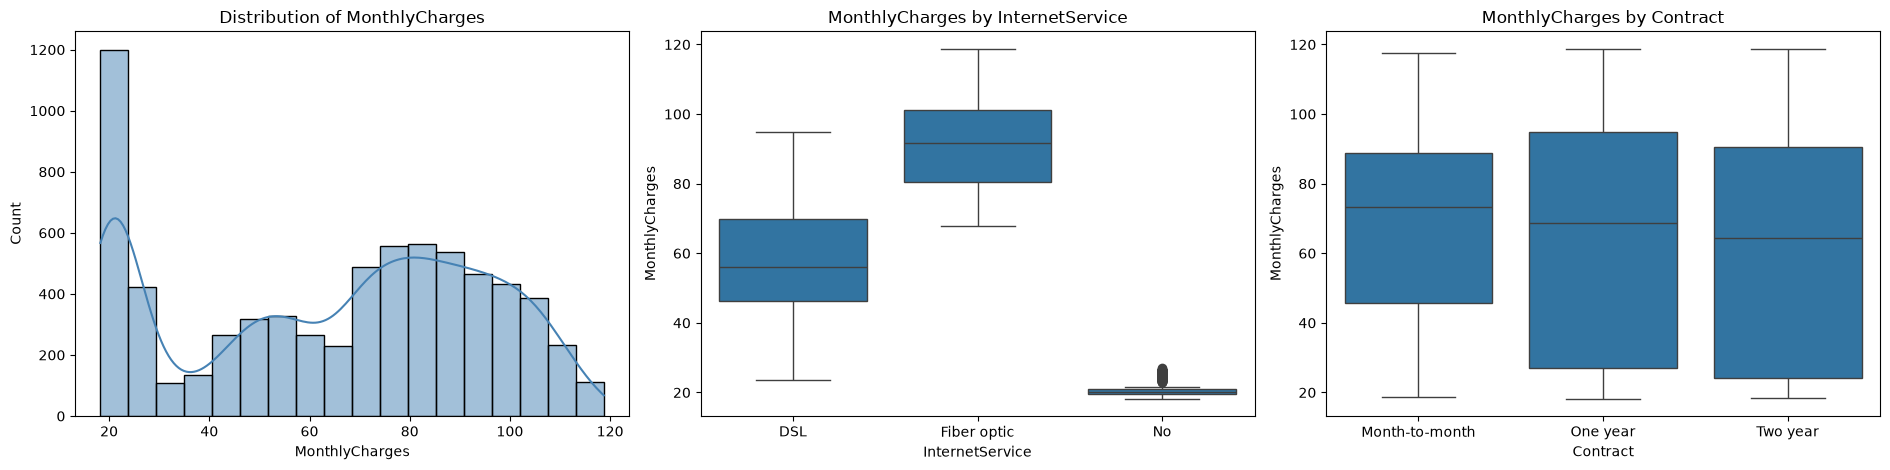

count    7043.000000
mean       64.761692
std        30.090047
min        18.250000
25%        35.500000
50%        70.350000
75%        89.850000
max       118.750000
Name: MonthlyCharges, dtype: float64


In [17]:
fig, axes = plt.subplots(1, 3, figsize=(19, 4.8))
sns.histplot(df['MonthlyCharges'], kde=True, ax=axes[0], color="steelblue")
axes[0].set_title("Distribution of MonthlyCharges")
sns.boxplot(data=df, x="InternetService", y='MonthlyCharges', ax=axes[1])
axes[1].set_title("MonthlyCharges by InternetService")
sns.boxplot(data=df, x="Contract", y='MonthlyCharges', ax=axes[2])
axes[2].set_title("MonthlyCharges by Contract")
plt.tight_layout()
plt.show()

print(df['MonthlyCharges'].describe())

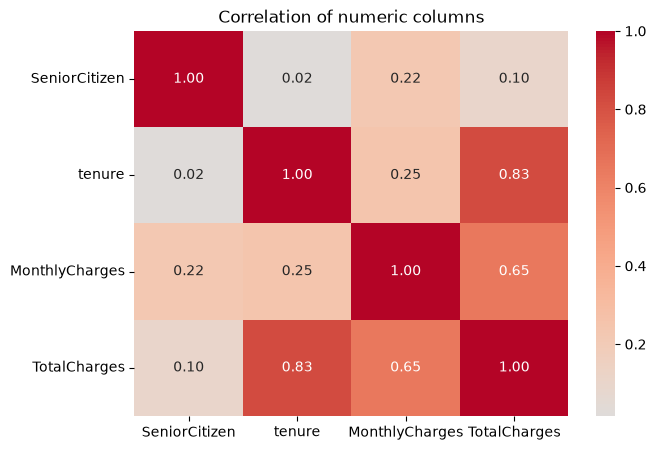

corr(TotalCharges, tenure x MonthlyCharges) = 0.9996


In [18]:
numeric_raw = df.select_dtypes(include="number")
plt.figure(figsize=(7, 5))
sns.heatmap(numeric_raw.corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation of numeric columns")
plt.show()

# Is TotalCharges basically the target in disguise?
leak_corr = np.corrcoef(df["TotalCharges"], df["tenure"] * df["MonthlyCharges"])[0, 1]
print(f"corr(TotalCharges, tenure x MonthlyCharges) = {leak_corr:.4f}")

Monthly charges is not normally distributed, and there is cluster of cheap phone only customers and a wide spread of internet customers.
The type of internet service shifts the prove level a lot (Fibre optic might be expensive and NO internet is cheap)
Total Charges is almost exactly tenure * Monthly Charges using it to predict Monthly Charges would be data leakage

## 5. Feature engineering

Every transformation below is **row-wise** (it only looks at one customer at a time), so it is safe to apply to the full table before the train/test split – no information leaks from test to train.

| Step | What we do | Why |
|---|---|---|
| Harmonise labels | `"No internet service"` and `"No phone service"` → `"No"` | These are duplicates of `InternetService == "No"` / `PhoneService == "No"` and only create redundant dummy columns |
| `num_addons` | Count of the 6 add-ons (security, backup, protection, support, TV, movies) | Each add-on adds to the bill – the count summarises this |
| `num_streaming`, `num_protection` | Counts inside the two add-on families | Streaming and protection are priced differently |
| `has_internet`, `is_fiber`, `has_phone`, `multiple_lines_flag` | Binary flags | Direct price drivers |
| `total_services` | add-ons + internet + phone + multiple lines | Overall "size" of the plan |
| `auto_pay`, `is_month_to_month`, `has_family` | Business-style flags | Capture contract / payment behaviour |
| `log_tenure`, `tenure_sq`, `tenure_group` | Non-linear versions of tenure | Customers' plans change non-linearly over their lifetime |

**Data leakage `TotalCharges`.** `TotalCharges ≈ tenure × MonthlyCharges`, so we are removing total charges too 

`customerID` is just an identifier and is dropped.

In [20]:
def engineer_features(data):
    # Row-wise feature engineering (no statistics learned from data -> no leakage).
    d = data.copy()
    d = d.drop(columns=["customerID"], errors="ignore")

    #Harmonise duplicate labels
    addon_cols = ["OnlineSecurity", "OnlineBackup", "DeviceProtection",
                  "TechSupport", "StreamingTV", "StreamingMovies"]
    d[addon_cols] = d[addon_cols].replace("No internet service", "No")
    d["MultipleLines"] = d["MultipleLines"].replace("No phone service", "No")

    # 2. Counts
    d["num_addons"] = (d[addon_cols] == "Yes").sum(axis=1)
    d["num_streaming"] = (d[["StreamingTV", "StreamingMovies"]] == "Yes").sum(axis=1)
    d["num_protection"] = (d[["OnlineSecurity", "OnlineBackup",
                              "DeviceProtection", "TechSupport"]] == "Yes").sum(axis=1)

    # 3. Binary flags
    d["has_internet"] = (d["InternetService"] != "No").astype(int)
    d["is_fiber"] = (d["InternetService"] == "Fiber optic").astype(int)
    d["has_phone"] = (d["PhoneService"] == "Yes").astype(int)
    d["multiple_lines_flag"] = (d["MultipleLines"] == "Yes").astype(int)
    d["total_services"] = (d["num_addons"] + d["has_internet"]
                           + d["has_phone"] + d["multiple_lines_flag"])
    d["auto_pay"] = d["PaymentMethod"].str.contains("automatic", case=False).astype(int)
    d["is_month_to_month"] = (d["Contract"] == "Month-to-month").astype(int)
    d["has_family"] = ((d["Partner"] == "Yes") | (d["Dependents"] == "Yes")).astype(int)

    # 4. Tenure transformations
    d["log_tenure"] = np.log1p(d["tenure"])
    d["tenure_sq"] = d["tenure"] ** 2
    d["tenure_group"] = pd.cut(d["tenure"], bins=[-1, 12, 24, 48, 60, np.inf],
                               labels=["0-12", "13-24", "25-48", "49-60", "61+"]).astype(str)

    # 5. Leakage control
    if not False:
        d = d.drop(columns=["TotalCharges"], errors="ignore")
    return d


X_all = engineer_features(df.drop(columns=['MonthlyCharges']))
y = df['MonthlyCharges']
print("Feature matrix shape:", X_all.shape)
X_all.head()

Feature matrix shape: (7043, 32)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,is_fiber,has_phone,multiple_lines_flag,total_services,auto_pay,is_month_to_month,has_family,log_tenure,tenure_sq,tenure_group
0,Female,0,Yes,No,1,No,No,DSL,No,Yes,...,0,0,0,2,0,1,1,0.693147,1,0-12
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,...,0,1,0,4,0,0,0,3.555348,1156,25-48
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,...,0,1,0,4,0,1,0,1.098612,4,0-12
3,Male,0,No,No,45,No,No,DSL,Yes,No,...,0,0,0,4,1,0,0,3.828641,2025,25-48
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,...,1,1,0,2,0,1,0,1.098612,4,0-12


In [23]:
new_feats = ["num_addons", "num_streaming", "num_protection", "total_services",
             "has_internet", "is_fiber", "has_phone", "multiple_lines_flag",
             "auto_pay", "is_month_to_month", "has_family", "log_tenure", "tenure_sq"]
corr_with_target = (pd.concat([X_all[new_feats], y], axis=1)
                      .corr()['MonthlyCharges'].drop('MonthlyCharges').sort_values(ascending=False))
corr_with_target.to_frame("corr with MonthlyCharges")

,corr with MonthlyCharges
total_services,0.851380
is_fiber,0.787066
has_internet,0.763557
num_addons,0.724706
num_streaming,0.717871
num_protection,0.564924
multiple_lines_flag,0.490434
has_phone,0.247398
log_tenure,0.239706
tenure_sq,0.238198


## Train / test split and preprocessing

* **70 % train / 30 % test** (same split as your original notebook, `random_state=42`).
* The preprocessing is wrapped in a `ColumnTransformer` inside a `Pipeline`, so scaling and encoding are learned **only from the training data** (and re-learned inside every cross-validation fold). This prevents leakage.
  * numeric columns → median imputation (safety net) + `StandardScaler`
  * categorical columns → most-frequent imputation (safety net) + `OneHotEncoder` (binary columns become a single 0/1 column)

In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X_all, y, test_size=0.3, random_state=42)
print("Train:", X_train.shape, " Test:", X_test.shape)
print(f"Target mean  train={y_train.mean():.2f}  test={y_test.mean():.2f}")

numeric_features = X_train.select_dtypes(include="number").columns.tolist()
categorical_features = X_train.select_dtypes(exclude="number").columns.tolist()
print("\nNumeric features    :", len(numeric_features), numeric_features)
print("Categorical features:", len(categorical_features), categorical_features)


def make_preprocessor(scale=True):
    num_steps = [("imputer", SimpleImputer(strategy="median"))]
    if scale:
        num_steps.append(("scaler", StandardScaler()))
    numeric_pipe = Pipeline(num_steps)
    categorical_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(drop="if_binary", handle_unknown="ignore", sparse_output=False)),
    ])
    return ColumnTransformer([
        ("num", numeric_pipe, numeric_features),
        ("cat", categorical_pipe, categorical_features),
    ])


def clean_names(names):
    return [n.split("__", 1)[1] for n in names]

Train: (4930, 32)  Test: (2113, 32)
Target mean  train=64.80  test=64.68

Numeric features    : 15 ['SeniorCitizen', 'tenure', 'num_addons', 'num_streaming', 'num_protection', 'has_internet', 'is_fiber', 'has_phone', 'multiple_lines_flag', 'total_services', 'auto_pay', 'is_month_to_month', 'has_family', 'log_tenure', 'tenure_sq']
Categorical features: 17 ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn', 'tenure_group']
